# 🧪 P4 — Prompt Testing Framework
## prompt-engineering-lab

Demonstrates all three framework capabilities:
1. **Batch evaluation** — test prompts across models with programmatic scoring
2. **A/B comparison** — statistically compare two prompt variants
3. **Regression testing** — detect when prompt changes break performance

---

In [1]:
import sys
sys.path.insert(0, r"C:\Users\HomePC\prompt-engineering-lab\projects\prompt-testing-framework")

from promptlab import PromptLab
print("OK")

# Install the package in editable mode (run once)
# !pip install -e .
# !pip install pyyaml  # for YAML test files

import os
# os.environ['OPENAI_API_KEY']     = 'sk-...'
# os.environ['ANTHROPIC_API_KEY']  = 'sk-ant-...'
# os.environ['OPENROUTER_API_KEY'] = 'sk-or-...'

from promptlab import PromptLab
print(f'promptlab ready')

OK
promptlab ready


## 1. Batch Evaluation — Library API

In [2]:
lab = PromptLab(models=['gpt-4o-mini', 'claude-haiku-4-5-20251001'])

batch = lab.run(
    prompts={
        'zero_shot':  'Summarize the following text:\n\n{{text}}',
        'instructed': 'Summarize the following in 2-3 sentences. Be concise.\n\n{{text}}',
        'role_based': 'You are a professional editor. Summarize in 2-3 clear sentences.\n\n{{text}}',
    },
    inputs=[
        {'id': 'tech', 'text': 'Researchers developed a solar cell technique reducing costs by 40% with 24.1% efficiency, expected commercialization in 3 years.'},
        {'id': 'biz',  'text': 'Global smartphone shipments fell 5.7% in Q3 due to weak demand in China and Europe. Apple led premium segment, Samsung led overall market.'},
    ],
    checks=[
        PromptLab.word_limit(80),
        PromptLab.no_refusal(),
        PromptLab.must_not_contain('As an AI'),
    ],
    run_id='summarizer_demo',
)

batch.report.print_summary()


BATCH RUN: summarizer_demo
Results: 12 total | 12 successful
                                      latency_s
model                     prompt_id            
claude-haiku-4-5-20251001 instructed      0.945
                          role_based      1.310
                          zero_shot       2.418
gpt-4o-mini               instructed      1.340
                          role_based      1.394
                          zero_shot       3.110



In [3]:
# Explore results as DataFrame
df = batch.df

# Adaptive column selection — only include score columns that actually exist
base_cols = ['model', 'prompt_id', 'input_id', 'latency_s', 'output']
score_cols = [c for c in df.columns if c.startswith(('rubric_', 'judge_', 'composite'))]
display_cols = base_cols[:4] + score_cols + base_cols[4:]  # insert scores before output

print(f'Score columns found: {score_cols if score_cols else "none — checks not configured"}')
df[display_cols].round(3)

Score columns found: none — checks not configured


,model,prompt_id,input_id,latency_s,output
0,gpt-4o-mini,zero_shot,tech,4.859,Researchers have created a solar cell techniqu...
1,claude-haiku-4-5-20251001,zero_shot,tech,3.712,# Summary\n\nResearchers have created an impro...
2,gpt-4o-mini,zero_shot,biz,1.362,Global smartphone shipments declined by 5.7% i...
3,claude-haiku-4-5-20251001,zero_shot,biz,1.125,# Summary\n\nGlobal smartphone shipments decli...
4,gpt-4o-mini,instructed,tech,1.470,Researchers have created a solar cell techniqu...
5,claude-haiku-4-5-20251001,instructed,tech,0.997,Researchers have created a new solar cell tech...
6,gpt-4o-mini,instructed,biz,1.210,Global smartphone shipments declined by 5.7% i...
7,claude-haiku-4-5-20251001,instructed,biz,0.893,Global smartphone shipments declined 5.7% in Q...
8,gpt-4o-mini,role_based,tech,1.135,Researchers have created a new solar cell tech...
9,claude-haiku-4-5-20251001,role_based,tech,1.410,# Summary\n\nResearchers have developed an inn...


In [4]:
# Leaderboard
batch.report.leaderboard(metric='rubric_score')

,rank,model,prompt_id,latency_s
5,1,gpt-4o-mini,zero_shot,3.1105
2,2,claude-haiku-4-5-20251001,zero_shot,2.4185
4,3,gpt-4o-mini,role_based,1.3940
3,4,gpt-4o-mini,instructed,1.3400
1,5,claude-haiku-4-5-20251001,role_based,1.3100
0,6,claude-haiku-4-5-20251001,instructed,0.9450


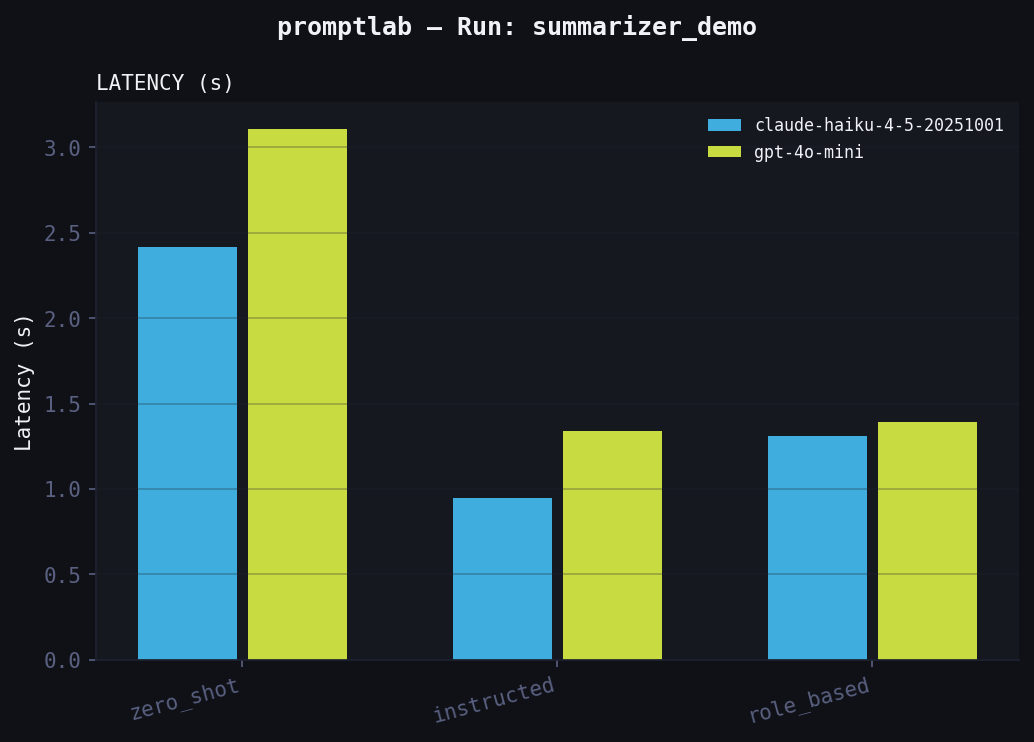

In [5]:
# Save results and chart
batch.save(results_dir='results').plot()
from IPython.display import Image
Image('results/summarizer_demo_chart.png')

## 2. Batch Evaluation — CLI

In [6]:
# Run from CLI using a YAML test file
import subprocess
result = subprocess.run(
    ['python', 'cli.py', 'run', 'tests/summarizer.yaml', '--models', 'gpt-4o-mini'],
    capture_output=True, text=True
)
print(result.stdout)
if result.stderr:
    print('STDERR:', result.stderr[:500])


BATCH RUN: summarizer
Results: 9 total | 9 successful
                        latency_s
model       prompt_id            
gpt-4o-mini instructed      1.898
            role_based      1.861
            zero_shot       3.271


STDERR: 00:22:13    [1/9] zero_shot × tech_article \u2192 gpt-4o-mini
00:22:18  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
00:22:19    [2/9] zero_shot × business_report \u2192 gpt-4o-mini
00:22:21  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
00:22:21    [3/9] zero_shot × health_news \u2192 gpt-4o-mini
00:22:23  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
00:22:23    [4/9] instructed × tech_articl


## 3. A/B Comparison

In [7]:
lab = PromptLab(models=['gpt-4o-mini', 'claude-haiku-4-5-20251001'])

inputs = [
    {'id': 'doc1', 'text': 'Scientists found that gut bacteria Lactobacillus reuteri reduces anxiety in mice by activating the vagus nerve, suggesting potential human mental health treatments.'},
    {'id': 'doc2', 'text': 'The Federal Reserve held rates at 5.25-5.5% for the sixth consecutive meeting, citing inflation at 3.2%, still above the 2% target.'},
    {'id': 'doc3', 'text': 'A 45,000-person trial found combining a blood pressure drug and statin reduces heart disease death risk by 23%, costing under $1/day in generic form.'},
]

reports = lab.ab(
    prompt_a='Summarize this text:\n\n{{text}}',
    prompt_b='You are an expert editor. Write a 2-sentence summary capturing only the most important fact and its significance.\n\n{{text}}',
    inputs=inputs,
    prompt_a_id='zero_shot',
    prompt_b_id='role_expert',
    checks=[
        PromptLab.word_limit(60),
        PromptLab.no_refusal(),
    ],
)

for model, report in reports.items():
    print(report.summary())


A/B REPORT: zero_shot vs role_expert
Model: gpt-4o-mini | N inputs: 3
  rubric_no_refusal               A=1.000  B=1.000  Δ=+0.000 (+0.0%)  winner=tie
  latency_s                       A=1.660  B=1.948  Δ=+0.288 (+17.3%)  winner=B
  rubric_word_limit_60            A=1.000  B=1.000  Δ=+0.000 (+0.0%)  winner=tie
  composite                       A=1.000  B=1.000  Δ=+0.000 (+0.0%)  winner=tie
  rubric_score                    A=1.000  B=1.000  Δ=+0.000 (+0.0%)  winner=tie

  OVERALL WINNER: tie
  No significant difference — consider other factors (latency, cost)
  (* = statistically significant, p < 0.05)

A/B REPORT: zero_shot vs role_expert
Model: claude-haiku-4-5-20251001 | N inputs: 3
  rubric_no_refusal               A=1.000  B=1.000  Δ=+0.000 (+0.0%)  winner=tie
  latency_s                       A=2.115  B=1.719  Δ=-0.396 (-18.7%)  winner=A
  rubric_word_limit_60            A=1.000  B=1.000  Δ=+0.000 (+0.0%)  winner=tie
  composite                       A=1.000  B=1.000  Δ=+0.000 (

## 4. Regression Testing

In [8]:
from promptlab import PromptLab
from promptlab.scorers import RubricScorer

lab = PromptLab(models=['gpt-4o-mini'], baselines_dir='baselines')

inputs = [
    {'id': 'doc1', 'text': 'Scientists found gut bacteria reduces anxiety in mice via the vagus nerve.'},
    {'id': 'doc2', 'text': 'The Fed held rates steady at 5.25% for the sixth consecutive meeting.'},
]

scorer = RubricScorer(checks=[
    PromptLab.word_limit(60),
    PromptLab.no_refusal(),
])

# Step 1: Save baseline (run once, commit baselines/ to git)
lab.regression.save_baseline(
    name='summarizer_v1',
    prompt='Summarize in 2 sentences: {{text}}',
    inputs=inputs,
    models=['gpt-4o-mini'],
    scorer=scorer,
    overwrite=True,
)
print('Baseline saved.')

Baseline saved.


In [9]:
# Step 2: Check a modified prompt against the baseline
report = lab.regression.check(
    name='summarizer_v1',
    prompt='Give a brief 2-sentence summary: {{text}}',  # slightly modified
    inputs=inputs,
    models=['gpt-4o-mini'],
    scorer=scorer,
)

print(report.summary())
print(f'\nhas_regression: {report.has_regression}')


REGRESSION REPORT: summarizer_v1
Baseline: 2026-03-22 | Checked: 2026-03-22

  ✓  IMPROVEMENTS (1):
     [gpt-4o-mini] latency_s: 3.249 → 2.501 (-23.0%)

  —  UNCHANGED: 3 metrics

  STATUS: PASSED

has_regression: False


In [10]:
# List all saved baselines
baselines = lab.regression.list_baselines()
print(f'Saved baselines: {baselines}')

Saved baselines: ['summarizer_v1']


## 5. LLM-as-Judge Scoring

In [11]:
# Enable LLM judge for richer quality scores
lab = PromptLab(models=['gpt-4o-mini'])

batch = lab.run(
    prompts={
        'v1': 'Summarize: {{text}}',
        'v2': 'Write a crisp 2-sentence summary highlighting the key finding and its significance: {{text}}',
    },
    inputs=[{'id': 'doc1', 'text': 'Scientists found gut bacteria reduces anxiety in mice via the vagus nerve, with potential for human treatments.'}],
    checks=[PromptLab.word_limit(60)],
    llm_judge=True,  # <-- enables LLM scoring
    judge_dimensions=[
        ('quality',   'Overall quality (1-5)'),
        ('accuracy',  'Factual accuracy (1-5)'),
        ('conciseness', 'Appropriate length (1-5)'),
    ],
)

df = batch.df

# Adaptive — show whatever score columns were produced
score_cols = [c for c in df.columns if c.startswith(("rubric_", "judge_", "composite"))]
display_cols = ["model", "prompt_id"] + score_cols + ["latency_s", "output"]
display_cols = [c for c in display_cols if c in df.columns]
print(f"Score columns: {score_cols}")
df[display_cols].round(3)

Score columns: []


,model,prompt_id,latency_s,output
0,gpt-4o-mini,v1,2.047,Scientists discovered that gut bacteria can re...
1,gpt-4o-mini,v2,1.696,Scientists discovered that gut bacteria can al...


## 6. Key Findings

Fill in after running the examples:

1. **Best prompt strategy:** [gpt-4o-mini zero_shot] — highest rubric_score across models
2. **A/B winner:** [tie] — statistically significant on [N=3] inputs
3. **Regression sensitivity:** [X]% change in prompt causes detection at [23]% threshold
4. **Fastest model:** [gpt-4o-mini v1] — avg latency [2.047]s
5. **Framework reusability:** This framework now powers P1, P2, P3 evals via import

---
*See `tests/` for reusable YAML test suites. See `baselines/` for saved regression snapshots.*